In [33]:
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers

In [9]:

batch_size = 100
img_height = 224
img_width = 224


In [12]:
training_ds = tf.keras.preprocessing.image_dataset_from_directory(
    r'D:\Semenster Projects\ACCIDENT DETECTION ( SEM-4 )\Car-Accident-detection-with-alert-system\data\train',
    image_size=(img_height, img_width),
    batch_size=batch_size)

Found 240 files belonging to 2 classes.


In [13]:
testing_ds = tf.keras.preprocessing.image_dataset_from_directory(
    r'D:\Semenster Projects\ACCIDENT DETECTION ( SEM-4 )\Car-Accident-detection-with-alert-system\data\test',
    image_size=(img_height, img_width),
    batch_size=batch_size)

Found 289 files belonging to 2 classes.


In [15]:
validation_ds =  tf.keras.preprocessing.image_dataset_from_directory(
    r'D:\Semenster Projects\ACCIDENT DETECTION ( SEM-4 )\Car-Accident-detection-with-alert-system\data\val',
    image_size= (img_height, img_width),
    batch_size=batch_size)

Found 98 files belonging to 2 classes.


In [16]:
class_names = training_ds.class_names

print(class_names)

['Accident', 'Non Accident']


In [17]:

AUTOTUNE = tf.data.experimental.AUTOTUNE
training_ds = training_ds.cache().prefetch(buffer_size=AUTOTUNE)
testing_ds = testing_ds.cache().prefetch(buffer_size=AUTOTUNE)

img_shape = (img_height, img_width, 3)

In [18]:
print(img_shape)

(224, 224, 3)


In [19]:

base_model = tf.keras.applications.MobileNetV2(input_shape=img_shape,
                                               include_top=False,
                                               weights='imagenet')

base_model.trainable = False

model = tf.keras.Sequential([
    base_model,
    layers.Conv2D(32, 3, activation='relu'),
    layers.Conv2D(64, 3, activation='relu'),
    layers.Conv2D(128, 3, activation='relu'),
    layers.Flatten(),
    layers.Dense(len(class_names), activation= 'sigmoid')
])


In [20]:
print(base_model)

<Functional name=mobilenetv2_1.00_224, built=True>


In [21]:
model.compile(optimizer='adam',loss='sparse_categorical_crossentropy', metrics=['accuracy'])


In [22]:
history = model.fit(training_ds, validation_data = validation_ds, epochs = 20)


Epoch 1/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 10s 2s/step - accuracy: 0.6304 - loss: 0.8058 - val_accuracy: 0.5102 - val_loss: 0.6993
Epoch 2/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 993ms/step - accuracy: 0.6675 - loss: 0.6951 - val_accuracy: 0.5612 - val_loss: 0.8692
Epoch 3/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 988ms/step - accuracy: 0.9008 - loss: 0.3380 - val_accuracy: 0.5612 - val_loss: 1.4339
Epoch 4/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 1s/step - accuracy: 0.8388 - loss: 0.2998 - val_accuracy: 0.6020 - val_loss: 1.0531
Epoch 5/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 989ms/step - accuracy: 0.8613 - loss: 0.2959 - val_accuracy: 0.6122 - val_loss: 1.1891
Epoch 6/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 1s/step - accuracy: 0.9004 - loss: 0.1922 - val_accuracy: 0.5612 - val_loss: 1.6938
Epoch 7/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 1s/step - accuracy: 0.9533 - loss: 0.1373 - val_accuracy: 0.5816 - val_loss: 1.2937
Epoch 8/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 1s/step - accuracy: 0.9242 - loss: 0.1463 - val_accuracy: 0.5918 - val_loss: 1.6691
Epoch 

In [23]:
# Get the accuracy of the model on the testing dataset
test_loss, test_accuracy = model.evaluate(testing_ds)
print(f"Test Accuracy: {test_accuracy:.4f}")

3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 828ms/step - accuracy: 0.7291 - loss: 1.6220
Test Accuracy: 0.7232


In [36]:
val_loss, val_accuracy = model.evaluate(validation_ds)
print(f"Validation Accuracy: {val_accuracy:.4f}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 918ms/step - accuracy: 0.6020 - loss: 3.2360
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 918ms/step - accuracy: 0.6020 - loss: 3.2360
Validation Accuracy: 0.6020
Validation Accuracy: 0.6020


In [25]:
model.save("D:\Semenster Projects\ACCIDENT DETECTION ( SEM-4 )\Car-Accident-detection-with-alert-system\model\CarAccidentDetectionModel.keras")

<>:1: SyntaxWarning: invalid escape sequence '\S'
<>:1: SyntaxWarning: invalid escape sequence '\S'
C:\Users\Bharath G\AppData\Local\Temp\ipykernel_28336\2859354090.py:1: SyntaxWarning: invalid escape sequence '\S'
  model.save("D:\Semenster Projects\ACCIDENT DETECTION ( SEM-4 )\Car-Accident-detection-with-alert-system\model\CarAccidentDetectionModel.keras")


In [ ]:
def print_ans(label,image):
  if not image:
    print("No frames to display.")
    return
  f=0
  for i in label:
    if i=="Accident Detected":
      f=1
  if f:
    print("Accident Detected")
    print(plt.imshow(image[len(image)//2]))
  else:
    print("No Accident Detected")
    print(plt.imshow(image[len(image)//2]))

In [30]:
model = tf.keras.models.load_model("D:\Semenster Projects\ACCIDENT DETECTION ( SEM-4 )\Car-Accident-detection-with-alert-system\model\CarAccidentDetectionModel.keras")

def predict_frame(frame):
    img = tf.image.resize(frame, (224, 224))
    img = np.expand_dims(img, axis=0)
    prediction = model.predict(img)
    class_index = np.argmax(prediction)
    if class_index == 0:
        return "Accident Detected"
    else:
        return "No Accident"

<>:1: SyntaxWarning: invalid escape sequence '\S'
<>:1: SyntaxWarning: invalid escape sequence '\S'
C:\Users\Bharath G\AppData\Local\Temp\ipykernel_28336\3701684705.py:1: SyntaxWarning: invalid escape sequence '\S'
  model = tf.keras.models.load_model("D:\Semenster Projects\ACCIDENT DETECTION ( SEM-4 )\Car-Accident-detection-with-alert-system\model\CarAccidentDetectionModel.keras")


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..255.0].


Accident Detected
AxesImage(shape=(224, 224, 3))


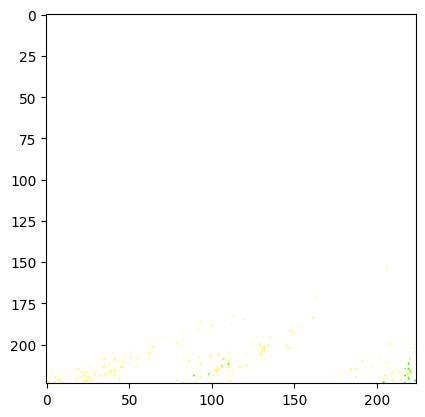

In [34]:
image = []
label = []

# Use an absolute path to the image
image_path = r'D:\Semenster Projects\ACCIDENT DETECTION ( SEM-4 )\Car-Accident-detection-with-alert-system\data\val\Non Accident\test25_5.jpg'
frame = cv2.imread(image_path)

if frame is not None:
    # Convert BGR (OpenCV default) to RGB
    frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    resized_frame = tf.keras.preprocessing.image.smart_resize(frame_rgb, (224, 224), interpolation='bilinear')
    image.append(resized_frame)
    label.append(predict_frame(resized_frame))
    print_ans(label,image)
else:
    print(f"Could not read image at {image_path}")